# Decoder Transformer — the writing half (GPT-style)

A **decoder-only** transformer writes text **one word at a time**. It reads everything written so far, guesses the
next word, adds it to the end, and repeats — like a very well-read autocomplete. GPT, Claude and Llama are all
decoder-only models.

Its one big rule: **no peeking at the future.** While learning, the model sees whole sentences, but each word may only
look at the words *before* it — otherwise predicting the next word would just be copying it.

How data flows through a decoder-only model (we build the pieces in exactly this order):
```
 "the cat sat on the"                    ← the text so far
      ↓  tokenizer                       ← words → ID numbers
 1. Embeddings                           ← ID numbers → meaning vectors
 2. + Positional Encoding                ← stamp each vector with its seat number
      ↓
 ┌─ Decoder block (repeated N times) ─────────────────────┐
 │ 3–5. Masked Multi-Head Self-Attention (causal mask)    │  ← each word looks only at earlier words
 │ 6.   Add & Norm                                        │  ← keep the original + steady the numbers
 │ 7.   Feed-Forward Network                              │  ← each word "thinks" on its own
 │ 6.   Add & Norm                                        │
 └────────────────────────────────────────────────────────┘
      ↓
 9.  Final LayerNorm + Linear layer + Softmax   ← a probability for every word in the vocabulary
      ↓
 11. Pick one (greedy / temperature / top-k)  → "mat"  → append it and go round again
```

**The full cycle:** Part 1 builds every piece by hand. Part 2 snaps them into a tiny GPT, **trains** it on a little
storybook, and lets it **write**.

**Companion notebooks:** `encoderTransformer.ipynb` (the reading half, BERT-style), `transformer.ipynb` (both halves
together, for translation) and `tinyGpt.ipynb` (a bigger version of Part 2, trained on Shakespeare).

In [1]:
# ==========================================
# 0. SETUP
# ==========================================
import math
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

torch.manual_seed(42)   # Fix the dice rolls so every run prints the same numbers
np.set_printoptions(precision=3, suppress=True)   # Print numbers to 3 decimals, no scientific notation
torch.set_printoptions(precision=3, sci_mode=False)

## Part 1 — The Building Blocks

### 1. Embeddings — turning words into numbers

A neural network can only do maths on numbers, so first every word (token) is swapped for an ID from a fixed
**vocabulary** (the model's dictionary), and then each ID is swapped for a **vector** — a list of numbers that
describes the word, like GPS coordinates for its meaning.

`nn.Embedding` is simply a big lookup table: one row per word in the vocabulary. The rows start out random and are
**learned** during training, so words used in similar ways (*"cat"*, *"dog"*) drift close together.

In [2]:
# ==========================================
# 1. EMBEDDINGS (word ID → meaning vector)
# ==========================================
vocabulary_size = 10000      # How many different tokens the model knows
embedding_dimension = 128    # How many numbers describe each token (GPT-2 uses 768)

# Step A: The lookup table - 10,000 rows, each a 128-number vector (random until trained)
embedding_layer = nn.Embedding(vocabulary_size, embedding_dimension)

print("=== THE MODEL'S INTERNAL DICTIONARY MATRIX ===")
print("Shape of full weight matrix:", embedding_layer.weight.shape)
print(embedding_layer.weight.data)
print("=" * 50 + "\n")

# Step B: A batch of 2 sentences, each already turned into 4 token IDs by a tokenizer
# Shape: (batch_size=2, sequence_length=4)
input_tokens = torch.tensor([
    [12, 45, 92, 17],
    [31, 11, 76, 12]      # Note: token 12 appears in both sentences
])

# Step C: Look up the vector for every token
embedded_sentence = embedding_layer(input_tokens)

print("=== FORWARD PASS TRACE ===")
print("1. Original Input Tensor:")
print(f"   Shape: {input_tokens.shape} -> (Batch Size, Sequence Length)")
print(f"   Values: {input_tokens.tolist()}\n")

print("2. Embedded Output Matrix:")
print(f"   Shape: {embedded_sentence.shape} -> (Batch Size, Sequence Length, Embedding Dim)")
print("   Values:")
print(embedded_sentence.data)
print("=" * 26)

# Step D: The same token always gets the same vector - no matter which sentence or position it's in
print("Token 12 gets the same vector in both sentences:", torch.equal(embedded_sentence[0, 0], embedded_sentence[1, 3]))

=== THE MODEL'S INTERNAL DICTIONARY MATRIX ===
Shape of full weight matrix: torch.Size([10000, 128])
tensor([[ 1.927,  1.487,  0.901,  ...,  0.340,  0.720,  0.411],
        [ 1.931,  1.012, -1.436,  ...,  0.566,  0.506,  0.222],
        [-0.685,  0.564, -1.507,  ...,  0.854, -0.490, -0.359],
        ...,
        [-0.058, -0.052, -0.871,  ..., -0.335, -0.043,  1.270],
        [ 0.852,  0.321,  0.985,  ..., -0.556,  0.215,  1.271],
        [-2.187, -0.133,  0.997,  ..., -0.851,  0.301, -0.808]])

=== FORWARD PASS TRACE ===
1. Original Input Tensor:
   Shape: torch.Size([2, 4]) -> (Batch Size, Sequence Length)
   Values: [[12, 45, 92, 17], [31, 11, 76, 12]]

2. Embedded Output Matrix:
   Shape: torch.Size([2, 4, 128]) -> (Batch Size, Sequence Length, Embedding Dim)
   Values:
tensor([[[-0.850, -0.699, -0.205,  ...,  0.382, -1.653, -0.381],
         [-1.039, -0.143,  1.130,  ..., -1.784, -1.239,  0.937],
         [ 0.132, -1.005,  0.125,  ..., -0.614, -1.303,  0.495],
         [-1.434, -0.

That last line is a problem in disguise: *"dog bites man"* and *"man bites dog"* give the model **exactly the same
three vectors**, just shuffled. Nothing yet says *where* each word sits. That's the job of the next piece.

### 2. Positional Encoding — giving every word a seat number

Self-attention (next section) compares every word with every other word, but the comparison **ignores order** —
to attention, a sentence is a bag of words. So before attention runs, we **add** a unique "position fingerprint"
to each word's vector: position 0 gets one pattern, position 1 another, and so on.

The original Transformer paper built these fingerprints out of sine and cosine waves of different speeds — like a
clock with many hands: the fast hands tell neighbouring positions apart, the slow hands tell far-apart positions
apart. Every position ends up with a unique combination.

=== 1. POSITIONAL ENCODING MATRIX ===
Positional encoding shape: torch.Size([1, 4, 128])
tensor([[ 0.000,  1.000,  0.000,  1.000,  0.000,  1.000,  0.000,  1.000],
        [ 0.841,  0.540,  0.762,  0.648,  0.682,  0.732,  0.605,  0.796],
        [ 0.909, -0.416,  0.987, -0.160,  0.997,  0.071,  0.963,  0.269],
        [ 0.141, -0.990,  0.517, -0.856,  0.778, -0.628,  0.930, -0.368]])

=== 2. FINAL INTEGRATED TRANSFORMER INPUT ===
Shape: Embeddings + positions: torch.Size([2, 4, 128])
tensor([[[-0.850,  0.301, -0.205,  ...,  1.382, -1.653,  0.619],
         [-0.197,  0.397,  1.892,  ..., -0.784, -1.239,  1.937],
         [ 1.041, -1.421,  1.112,  ...,  0.386, -1.303,  1.495],
         [-1.292, -1.866,  0.527,  ...,  0.970,  1.272,  2.085]],

        [[ 0.308,  0.872,  0.037,  ...,  0.860,  0.942,  0.988],
         [ 1.112, -0.642, -0.272,  ...,  1.220,  0.325,  2.319],
         [ 0.622, -1.470, -0.610,  ...,  1.239,  0.740,  2.561],
         [-0.709, -1.689,  0.312,  ...,  1.382, -1.652,

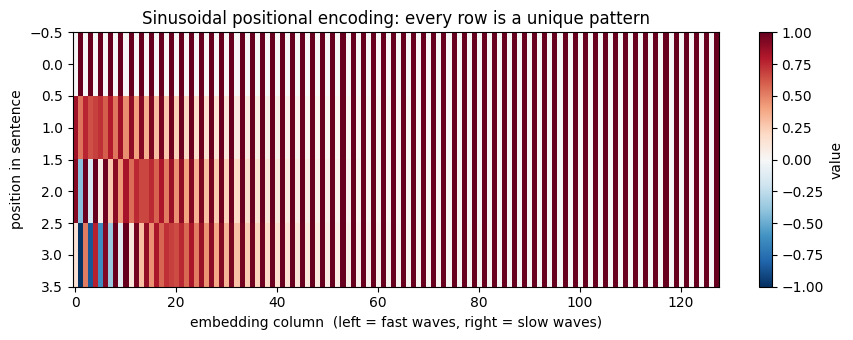

In [3]:
# ==========================================
# 2. POSITIONAL ENCODING (sine/cosine "seat numbers")
# ==========================================
sequence_length = embedded_sentence.shape[1]   # 4 words per sentence

def positional_encoding(sequence_length, dimension):
    # 1. Positions as a column: (seq_len, 1) -> [[0], [1], [2], [3]]
    position = torch.arange(0, sequence_length, dtype=torch.float32).unsqueeze(1)

    # 2. div_term sets the speed of each wave (fast on the left columns, slow on the right)
    div_term = torch.exp(torch.arange(0, dimension, 2) * (-torch.log(torch.tensor(10000.0)) / dimension))

    # 3. A blank matrix to fill in: (sequence_length, dimension)
    pe = torch.zeros(sequence_length, dimension)

    # 4. Even columns (0, 2, 4...) get sine waves, odd columns (1, 3, 5...) get cosine waves
    pe[:, 0::2] = torch.sin(position * div_term)
    pe[:, 1::2] = torch.cos(position * div_term)

    # 5. Add a batch dimension so it lines up with embedded_sentence: (4, 128) → (1, 4, 128)
    return pe.unsqueeze(0)

pe = positional_encoding(sequence_length, embedding_dimension)

# Add the position stamps to the word vectors
final_transformer_input = embedded_sentence + pe

print("=== 1. POSITIONAL ENCODING MATRIX ===")
print("Positional encoding shape:", pe.shape)   # (1, positions, numbers per position)
print(pe[0, :, :8])   # Shows the first 8 columns

print("\n=== 2. FINAL INTEGRATED TRANSFORMER INPUT ===")
print("Shape: Embeddings + positions:", final_transformer_input.shape)
print(final_transformer_input.data)

print("Token 12 still identical in both sentences?", torch.equal(final_transformer_input[0, 0], final_transformer_input[1, 3]))   # Seat 0 vs seat 3

# Picture it - each row is one position's fingerprint
plt.figure(figsize=(9, 3.5))
plt.imshow(pe[0], cmap="RdBu_r", vmin=-1, vmax=1, aspect="auto")   # Blue = -1, white = 0, red = +1
plt.colorbar(label="value")
plt.xlabel("embedding column  (left = fast waves, right = slow waves)")
plt.ylabel("position in sentence")
plt.title("Sinusoidal positional encoding: every row is a unique pattern")
plt.tight_layout()
plt.show()

Read the picture left to right: the first columns flip colour every row or two (fast hands), the right-hand columns
barely change over 4 positions (slow hands) — which is why they show up as plain stripes: sine columns sit near 0
(white), cosine columns near 1 (red). No two rows are identical.

**Modern models don't all use this exact method.** GPT-2 and `tinyGpt.ipynb` use **learned** position embeddings
(just another `nn.Embedding`, indexed by position); Llama and most recent LLMs use **RoPE** (rotary embeddings, which
*rotate* the query and key vectors by an angle that depends on position). The goal is always the same: tell
attention where each word is.

### 3. Self-Attention — how words look at each other

This is the heart of the Transformer. Picture a **library visit**: you walk in with a **query** (*"I need something
about sleepy animals"*). Every book has a **key** (the label on its spine) and a **value** (what's actually inside).
You compare your query against every key, score how well each matches, and walk out with a **blend** of the books'
contents — mostly from the best matches, a little from the rest.

In a sentence, **every word does this at once**: each word is a reader (query) *and* a book (key + value) for all
the others. It takes four steps — **score, scale, soften, blend**:

$$\text{Attention}(Q, K, V) = \text{softmax}\!\left(\frac{QK^\top}{\sqrt{d_k}}\right) V$$

| Step | Maths | Plain English |
|---|---|---|
| 1. Score | $QK^\top$ | Dot product: how well does each query match each key? |
| 2. Scale | $\div \sqrt{d_k}$ | Shrink the scores so softmax doesn't become winner-takes-all ($d_k$ = numbers per key) |
| 3. Soften | softmax | Turn each row of scores into percentages that add up to 1 (the **attention weights**) |
| 4. Blend | $\times V$ | Each word's output = weighted average of all the values |

Let's do it by hand with 2 tiny words, each described by 2 numbers.

In [4]:
# ==========================================
# 3A. SELF-ATTENTION BY HAND (NumPy, 2 words × 2 numbers)
# ==========================================
Q = np.array([[1.0, 0.0],     # Word 1's question: "what am I looking for?"
              [0.0, 1.0]])    # Word 2's question
K = np.array([[1.0, 0.0],     # Word 1's label: "what do I contain?"
              [0.5, 1.0]])    # Word 2's label
V = np.array([[2.0, 1.0],     # Word 1's content: "what I share if picked"
              [1.0, 3.0]])    # Word 2's content

# Step 1 - SCORE: every query dotted with every key. Row = the reader, column = the book
scores = Q @ K.T
print("1. Raw scores (row i = how much word i matches each word):\n", scores)

# Step 2 - SCALE: divide by √d_k so bigger vectors don't give giant scores
d_k = K.shape[1]
scaled = scores / np.sqrt(d_k)
print("\n2. Scaled scores (÷ √2):\n", scaled)

# Step 3 - SOFTEN: softmax each row so it becomes percentages adding to 1
def softmax(z):
    e = np.exp(z - z.max(axis=-1, keepdims=True))   # Subtract the max first - avoids overflow, same answer
    return e / e.sum(axis=-1, keepdims=True)

weights = softmax(scaled)
print("\n3. Attention weights (each row sums to 1):\n", weights)
print("   Row sums:", weights.sum(axis=1))

# Step 4 - BLEND: each word's new vector = weighted mix of every word's value
output = weights @ V
print("\n4. Output (each word now carries context from the other):\n", output)

1. Raw scores (row i = how much word i matches each word):
 [[1.  0.5]
 [0.  1. ]]

2. Scaled scores (÷ √2):
 [[0.707 0.354]
 [0.    0.707]]

3. Attention weights (each row sums to 1):
 [[0.587 0.413]
 [0.33  0.67 ]]
   Row sums: [1. 1.]

4. Output (each word now carries context from the other):
 [[1.587 1.825]
 [1.33  2.34 ]]


Read row 1 of the weights: word 1 spends **~59%** of its attention on itself and **~41%** on word 2, so its output
`[1.587, 1.825]` is mostly word 1's value `[2, 1]` with a good dose of word 2's value `[1, 3]` mixed in. The word
went in "alone" and came out **aware of its neighbour** — that's what "contextual representation" means.

**Where do Q, K and V come from?** Above we typed them in. In a real model they are all made **from the same input
vectors `x`**, each through its own learned linear layer (a learned "translation"). Same word, three roles. That's
why it's called *self*-attention: the sentence attends to itself.

In [5]:
# ==========================================
# 3B. SELF-ATTENTION IN PYTORCH (Q, K, V learned from the same input)
# ==========================================
# 1. Three linear layers that turn each word into its query, key and value
# In a real transformer, these weights are learned during training
W_q = nn.Linear(embedding_dimension, embedding_dimension, bias=False)
W_k = nn.Linear(embedding_dimension, embedding_dimension, bias=False)
W_v = nn.Linear(embedding_dimension, embedding_dimension, bias=False)

# Project our input into Queries, Keys, and Values
Q = W_q(final_transformer_input)  # Shape: (2, 4, 128)
K = W_k(final_transformer_input)  # Shape: (2, 4, 128)
V = W_v(final_transformer_input)  # Shape: (2, 4, 128)

print("=== 1. MATRICES GENERATED ===")
print("Query (Q) Shape:", Q.shape)
print("Key (K) Shape:", K.shape)
print("Value (V) Shape:", V.shape, "\n")

# 2. Step-by-step attention maths
# Step A: Raw scores - Q times K turned on its side (transpose the last two dimensions of K)
scores = torch.matmul(Q, K.transpose(-2, -1))  # Shape: (2, 4, 4)
print("A. Raw scores (row i = how much word i matches each word):\n", scores)

# Step B: Scale the scores
d_k = K.size(-1)
scaled_scores = scores / math.sqrt(d_k)
print(f"\nB. Scaled scores (÷ √{d_k}):\n", scaled_scores)

# Step C: Softmax turns each row into attention weights (percentages)
attention_weights = torch.softmax(scaled_scores, dim=-1)
print("\n=== C. ATTENTION WEIGHTS (PROBABILITIES) ===")
print("Shape:", attention_weights.shape, "-> (Batch, Word_Q, Word_K)")
print("Row sums:", attention_weights.sum(dim=-1))
print(attention_weights.data, "\n")

# Step D: Blend - multiply the weights by the values
attention_output = torch.matmul(attention_weights, V)  # Shape: (2, 4, 128)

print("=== D. FINAL SELF-ATTENTION OUTPUT ===")
print("Shape:", attention_output.shape, "-> (Batch, Seq_Len, Embedding_Dim)")
print(attention_output.data)

=== 1. MATRICES GENERATED ===
Query (Q) Shape: torch.Size([2, 4, 128])
Key (K) Shape: torch.Size([2, 4, 128])
Value (V) Shape: torch.Size([2, 4, 128]) 

A. Raw scores (row i = how much word i matches each word):
 tensor([[[  8.397,   4.040,   6.175,   3.227],
         [  6.192,  -6.658,  16.473,   5.910],
         [ -1.758,  -1.248,   3.295,   3.864],
         [ 13.140,   0.412,   9.165,   9.276]],

        [[ -2.371,  -1.599, -11.330,  -2.225],
         [  2.700,   0.167,   3.464,   5.901],
         [  6.376,  -1.249,  -9.841,   4.960],
         [  6.123,   9.368,   6.422,   9.819]]], grad_fn=<UnsafeViewBackward0>)

B. Scaled scores (÷ √128):
 tensor([[[ 0.742,  0.357,  0.546,  0.285],
         [ 0.547, -0.588,  1.456,  0.522],
         [-0.155, -0.110,  0.291,  0.341],
         [ 1.161,  0.036,  0.810,  0.820]],

        [[-0.210, -0.141, -1.001, -0.197],
         [ 0.239,  0.015,  0.306,  0.522],
         [ 0.564, -0.110, -0.870,  0.438],
         [ 0.541,  0.828,  0.568,  0.868]]],

The weights are spread out fairly evenly because the linear layers are random — nothing has been learned yet. After
training, a row like *"it"* in *"the animal didn't cross the street because **it** was tired"* concentrates its
weight on *"animal"*.

The output has the **same shape as the input**: 4 words × 128 numbers in, 4 words × 128 numbers out. That's what
lets us stack attention layers on top of each other.

### 4. The Causal Mask — no peeking at the future

Sometimes a word must **not** be allowed to look at certain other words. The trick is always the same: set the
forbidden scores to **−∞** before softmax. Since $e^{-\infty} = 0$, those words get **exactly 0%** attention, and the
remaining percentages still add up to 1.

For a writer the forbidden words are the **later** ones. When the model learns to predict word 4, it must only see
words 1–3, otherwise it would just copy the answer. The mask is a lower triangle: row *i* (the word doing the
looking) can see columns 0…*i* — itself and everything before it.

Causal mask (1 = allowed, 0 = blocked):
 tensor([[1, 0, 0, 0],
        [1, 1, 0, 0],
        [1, 1, 1, 0],
        [1, 1, 1, 1]], dtype=torch.int32)

=== 1. SCORES AFTER CAUSAL MASK ===
tensor([[ 0.742,   -inf,   -inf,   -inf],
        [ 0.547, -0.588,   -inf,   -inf],
        [-0.155, -0.110,  0.291,   -inf],
        [ 1.161,  0.036,  0.810,  0.820]]) 

=== 2. FINAL ATTENTION WEIGHTS (PROBABILITIES) ===
tensor([[1.000, 0.000, 0.000, 0.000],
        [0.757, 0.243, 0.000, 0.000],
        [0.277, 0.290, 0.433, 0.000],
        [0.365, 0.119, 0.257, 0.259]])


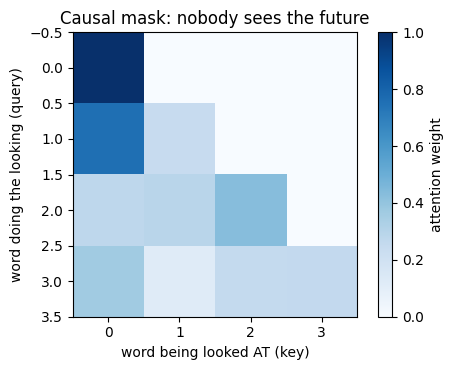

In [6]:
# ==========================================
# 4. CAUSAL MASK (no peeking at the future)
# ==========================================
scaled_4x4 = scaled_scores[0].detach()   # Sentence 1's 4×4 scaled scores from section 3B

# 1. Mark the future: torch.triu keeps the upper triangle of 1s. diagonal=1 keeps the main diagonal open (0)
mask = torch.triu(torch.ones(sequence_length, sequence_length), diagonal=1)
# Resulting mask matrix (1 = blocked):
# [[0, 1, 1, 1],
#  [0, 0, 1, 1],
#  [0, 0, 0, 1],
#  [0, 0, 0, 0]]
print("Causal mask (1 = allowed, 0 = blocked):\n", (mask == 0).int())

# 2. Turn the 1s into -inf and keep the 0s as 0.0
causal_mask = mask.masked_fill(mask == 1, float("-inf"))

# 3. Add the mask to the scaled scores - anything plus -inf is -inf
masked_scores = scaled_4x4 + causal_mask
print("\n=== 1. SCORES AFTER CAUSAL MASK ===")
print(masked_scores.data, "\n")

# 4. Softmax - every future slot becomes exactly 0
causal_attention_weights = torch.softmax(masked_scores, dim=-1)
print("=== 2. FINAL ATTENTION WEIGHTS (PROBABILITIES) ===")
print(torch.round(causal_attention_weights, decimals=4).data)   # Upper right triangle is exactly 0

# 5. Picture the causal pattern
plt.figure(figsize=(5, 3.8))
plt.imshow(causal_attention_weights, cmap="Blues", vmin=0, vmax=1)
plt.colorbar(label="attention weight")
plt.xlabel("word being looked AT (key)")
plt.ylabel("word doing the looking (query)")
plt.title("Causal mask: nobody sees the future")
plt.tight_layout()
plt.show()

Everything above the diagonal is exactly 0 — the future is invisible. Word 1 can only look at itself (100%), and the
**last** row is identical to the unmasked weights in section 3B: the last word is allowed to see everything, so the
mask changes nothing for it.

**What about `<pad>`?** Decoders pad short sentences at the **end**. Since padding comes *after* the real words, the
causal mask already stops every real word from looking at it. The only extra step is to not *score* the `<pad>`
positions when training (the `ignore_index=` setting in Part 2).

In PyTorch's built-in layers you rarely build this by hand: `nn.Transformer.generate_square_subsequent_mask(n)` makes
exactly this 0 / −∞ matrix.

### 5. Multi-Head Attention — several readers at once

One attention pattern gives each word **one way** of looking at the sentence. But language has many relationships at
the same time: which noun does *"it"* refer to, which adjective describes which noun, which verb goes with which
subject…

**Multi-head attention** runs several attention "heads" side by side, like a team of readers each hunting for a
different kind of clue. The 128 numbers per word are **split** between the heads (8 heads × 16 numbers each), every
head does its own score–scale–soften–blend, and the results are glued back together and mixed by one final linear
layer. Splitting (rather than copying) means 8 heads cost about the same as 1 big head.

In [7]:
# ==========================================
# 5. MULTI-HEAD ATTENTION
# ==========================================
num_heads = 8
batch_size = final_transformer_input.shape[0]   # 2 sentences
d_k = embedding_dimension // num_heads          # Dimension per head = 16 (128 / 8)
print("Numbers each head works with:", d_k)

# 1. Linear projections for the full 128 numbers (the heads get split out afterwards)
W_q = nn.Linear(embedding_dimension, embedding_dimension, bias=False)
W_k = nn.Linear(embedding_dimension, embedding_dimension, bias=False)
W_v = nn.Linear(embedding_dimension, embedding_dimension, bias=False)
out_project = nn.Linear(embedding_dimension, embedding_dimension)   # Mixes the heads' findings back together

# 2. Project to get Q, K, V
Q = W_q(final_transformer_input)   # (2, 4, 128)
K = W_k(final_transformer_input)   # (2, 4, 128)
V = W_v(final_transformer_input)   # (2, 4, 128)

# 3. THE SPLIT STEP: reshape and swap axes so each head gets its own slice
# From (2, 4, 128) -> view (2, 4, 8, 16) -> transpose (2, 8, 4, 16) = (Batch, Heads, Seq_Len, d_k)
Q = Q.view(batch_size, sequence_length, num_heads, d_k).transpose(1, 2)
K = K.view(batch_size, sequence_length, num_heads, d_k).transpose(1, 2)
V = V.view(batch_size, sequence_length, num_heads, d_k).transpose(1, 2)

print("=== 1. HEAD SPLIT CONFIGURATION ===")
print("Shape of Q per head:", Q.shape, "-> (Batch, Heads, Seq_Len, Dim_Per_Head)\n")

# 4. Standard attention maths for all 8 heads at once - plus the causal mask
future = torch.triu(torch.ones(sequence_length, sequence_length, dtype=torch.bool), diagonal=1)   # True = a word in the future
scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(d_k)   # (2, 8, 4, 4)
scores = scores.masked_fill(future, float("-inf"))              # The (4, 4) mask is shared by every sentence and every head
attention_weights = torch.softmax(scores, dim=-1)               # (2, 8, 4, 4): one 4×4 pattern per head
head_outputs = torch.matmul(attention_weights, V)               # (2, 8, 4, 16)
print("Most attention ANY head pays to a future word:", attention_weights.triu(diagonal=1).max().item(), "\n")

# 5. THE MERGE STEP: glue the heads back together
# Swap back to (Batch, Seq_Len, Heads, d_k) -> (2, 4, 8, 16)
# Then flatten the last two dimensions back into d_model -> (2, 4, 128)
merged_heads = head_outputs.transpose(1, 2).contiguous().view(batch_size, sequence_length, embedding_dimension)

print("=== 2. MERGED HEADS COMPOSITE ===")
print("Shape after merging heads:", merged_heads.shape, "-> (Batch, Seq_Len, d_model)\n")

# 6. Final linear layer mixes what the 8 heads found
final_attention_output = out_project(merged_heads)
print("=== 3. FINAL LAYER TRANSFORMED OUTPUT ===")
print("Output Shape:", final_attention_output.shape)
print("Attention weights:", attention_weights.shape)

Numbers each head works with: 16
=== 1. HEAD SPLIT CONFIGURATION ===
Shape of Q per head: torch.Size([2, 8, 4, 16]) -> (Batch, Heads, Seq_Len, Dim_Per_Head)

Most attention ANY head pays to a future word: 0.0 

=== 2. MERGED HEADS COMPOSITE ===
Shape after merging heads: torch.Size([2, 4, 128]) -> (Batch, Seq_Len, d_model)

=== 3. FINAL LAYER TRANSFORMED OUTPUT ===
Output Shape: torch.Size([2, 4, 128])
Attention weights: torch.Size([2, 8, 4, 4])


The weights shape shows the point: **8 separate 4×4 attention patterns per sentence**, one per head. The parameter
count is $3 \times 128 \times 128 + (128 \times 128 + 128) = 65{,}664$ — the Q, K, V and output projections. The
number of heads does **not** change it.

The causal mask works the same with many heads: one 4×4 mask is shared by every sentence and all 8 heads, so no head
can sneak a look at a later word.

### 6. Add & Norm — residual connections and layer normalization

Every sub-layer (attention, feed-forward) is wrapped in two helpers:

- **Add (residual connection)**: output = input **+** sub-layer(input). The sub-layer only has to learn a *correction*
  to what's already there, not rebuild the word from scratch. It's also a highway for gradients (the learning
  signal) to flow straight back through a deep stack of layers — without it, 12, 24 or 96 layers wouldn't train.
- **Norm (LayerNorm)**: rescales each word's numbers to average 0 and spread 1, so values can't slowly blow up or
  shrink as they pass through layer after layer. Like re-tuning an instrument between songs.

In [8]:
# ==========================================
# 6. ADD & NORM
# ==========================================
# LayerNorm used after attention
norm1 = nn.LayerNorm(embedding_dimension)

# 1. "Add" the original input to the attention output
x_residual_1 = final_transformer_input + final_attention_output
# 2. "Norm" the combined result
x_norm_1 = norm1(x_residual_1)

print(f"Before norm → average {x_residual_1.mean():.2f}, spread {x_residual_1.std():.2f}")
print(f"After norm  → average {x_norm_1.mean():.2f}, spread {x_norm_1.std():.2f}")

print("\n=== POST ADD & NORM ===")
print("Shape:", x_norm_1.shape)
print("Mean value per word (should be close to 0):")
print(torch.round(x_norm_1.mean(dim=-1), decimals=4).data)

Before norm → average 0.45, spread 1.13
After norm  → average 0.00, spread 1.00

=== POST ADD & NORM ===
Shape: torch.Size([2, 4, 128])
Mean value per word (should be close to 0):
tensor([[0., 0., 0., 0.],
        [-0., -0., 0., 0.]])


**Post-norm vs pre-norm.** The original paper (and the code above) normalizes *after* adding:
`LayerNorm(x + sublayer(x))`. Almost every modern model (GPT-2 onward, `tinyGpt.ipynb`) normalizes *before* the
sub-layer instead: `x + sublayer(LayerNorm(x))` — it trains more stably when stacking many layers. In PyTorch's
built-in layers this is the `norm_first=True` switch.

### 7. Position-wise Feed-Forward Network — each word thinks on its own

Attention is where words **talk to each other**. The feed-forward network (FFN) is where each word **thinks by itself**
about what it just heard. It's a small two-layer network applied to every word **separately** (that's what
"position-wise" means — same network, each position on its own, no mixing between words).

It widens each word's vector (128 → 512, the usual 4×), applies a non-linearity (GELU here; the original paper used
ReLU, and Llama-style models use SwiGLU), then shrinks it back to 128 so the next layer gets the same shape. Then
comes Add & Norm again, just like after attention.

In [9]:
# ==========================================
# 7. POSITION-WISE FEED-FORWARD NETWORK
# ==========================================
# 1. Build the layers
norm2 = nn.LayerNorm(embedding_dimension)          # LayerNorm for the second Add & Norm
d_ff = embedding_dimension * 4                     # 512 (128 × 4): the widened size
ffn_layer1 = nn.Linear(embedding_dimension, d_ff)
ffn_activation = nn.GELU()                         # Non-linearity - lets it learn more than straight-line patterns
ffn_layer2 = nn.Linear(d_ff, embedding_dimension)

# Step B1: Widen 128 → 512
ffn_out = ffn_layer1(x_norm_1)
# Step B2: Apply the non-linearity
ffn_out = ffn_activation(ffn_out)
# Step B3: Shrink back 512 → 128
ffn_processed = ffn_layer2(ffn_out)

print("=== POST FFN PROCESSING ===")
print("Shape:", ffn_processed.shape, "-> (Preserves original layout)\n")

# Proof it's position-wise: word 3 run alone gives the same answer as word 3 inside the sentence
alone = ffn_layer2(ffn_activation(ffn_layer1(x_norm_1[:, 3:4, :])))
print("Word 3 alone == word 3 in the sentence:", torch.allclose(alone, ffn_processed[:, 3:4, :], atol=1e-6))

# Who holds the weights?
ffn_params  = sum(p.numel() for layer in (ffn_layer1, ffn_layer2) for p in layer.parameters())
attn_params = sum(p.numel() for layer in (W_q, W_k, W_v, out_project) for p in layer.parameters())
print(f"Feed-forward parameters: {ffn_params:,}")        # 131,712
print(f"Attention parameters   : {attn_params:,}")       # 65,664
print(f"Share held by the FFN  : {ffn_params / (ffn_params + attn_params):.0%}")   # 67%

# Step C: Second Add & Norm (residual connection around the FFN)
x_residual_2 = x_norm_1 + ffn_processed       # "Add" the pre-FFN vector to the post-FFN vector
final_block_output = norm2(x_residual_2)      # "Norm" the result

print("\n=== FINAL TRANSFORMER BLOCK OUTPUT ===")
print("Shape:", final_block_output.shape)

=== POST FFN PROCESSING ===
Shape: torch.Size([2, 4, 128]) -> (Preserves original layout)

Word 3 alone == word 3 in the sentence: True
Feed-forward parameters: 131,712
Attention parameters   : 65,664
Share held by the FFN  : 67%

=== FINAL TRANSFORMER BLOCK OUTPUT ===
Shape: torch.Size([2, 4, 128])


The humble FFN holds **about two thirds** of each layer's weights. Attention decides *where information flows*; the
feed-forward layers do much of the *storing and transforming* — a lot of what a large language model "knows" is
thought to live in them.

### 8. Putting It Together — one Decoder block from scratch

Now we snap sections 5–7 together into the unit that gets stacked 12, 24, 96… times in real models (GPT-2 small has
12), using the **pre-norm** layout from the note after section 6. The causal mask is built **inside** the block, so it
can never be forgotten:

```
x ─┬─> LayerNorm ─> Masked Multi-Head Attention ─> (+) ─┬─> LayerNorm ─> Feed-Forward ─> (+) ─> out
   └────────────────────────────────────────────────┘   └─────────────────────────────────┘
                  residual connection                           residual connection
```

Two checks: changing the **last** word must not change the outputs of earlier words, and our block must have
exactly as many weights as PyTorch's version.

In [10]:
# ==========================================
# 8. ONE DECODER BLOCK FROM SCRATCH
# ==========================================
class DecoderBlock(nn.Module):
    def __init__(self, d_model=128, num_heads=8, dim_feedforward=512, dropout=0.1):
        super().__init__()
        # 1. Multi-head self-attention (section 5) - PyTorch's built-in version of what we wrote by hand
        self.attention = nn.MultiheadAttention(d_model, num_heads, dropout=dropout, batch_first=True)
        # 2. Feed-forward network (section 7): widen → GELU → shrink
        self.ffn = nn.Sequential(
            nn.Linear(d_model, dim_feedforward),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(dim_feedforward, d_model)
        )
        # 3. Two LayerNorms (section 6) - one before attention, one before the FFN
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        # 4. Dropout - during training, randomly switches off a few numbers so the model can't lean on any one too hard
        self.dropout1 = nn.Dropout(dropout)
        self.dropout2 = nn.Dropout(dropout)

    def forward(self, x):
        # Step 0: a causal mask sized for however many words came in (0 = allowed, -inf = future)
        causal_mask = nn.Transformer.generate_square_subsequent_mask(x.shape[1])
        # Step A: words look at EARLIER words only - normalize, attend, add back
        h = self.norm1(x)
        attn_output, _ = self.attention(h, h, h, attn_mask=causal_mask)
        x = x + self.dropout1(attn_output)
        # Step B: each word thinks on its own - normalize, FFN, add back
        x = x + self.dropout2(self.ffn(self.norm2(x)))
        return x

# 1. Build one block with the sizes we've used all along
decoder_block = DecoderBlock(d_model=128, num_heads=8, dim_feedforward=512)
decoder_block.eval()   # Turn dropout off so the demo gives repeatable numbers

# 2. Run our sentence through it
block_output = decoder_block(final_transformer_input)
print("Block output shape:", block_output.shape)   # (2, 4, 128) in → (2, 4, 128) out

# 3. Proof the causal mask works: change the LAST word - earlier words must not change at all
changed = final_transformer_input.clone()
changed[:, -1] = torch.randn(128) * 10            # Wild new numbers for word 4
with torch.no_grad():
    before = decoder_block(final_transformer_input)
    after = decoder_block(changed)
print("Words 1-3 unaffected by word 4:", torch.allclose(before[:, :-1], after[:, :-1], atol=1e-5))
print("Word 4 itself did change      :", not torch.allclose(before[:, -1], after[:, -1], atol=1e-5))

# 4. Compare with PyTorch (same settings: GELU, pre-norm)
count = lambda m: sum(p.numel() for p in m.parameters())   # Add up every weight and bias
builtin_layer = nn.TransformerEncoderLayer(d_model=128, nhead=8, dim_feedforward=512, dropout=0.1,
                                           activation="gelu", batch_first=True, norm_first=True)
builtin_decoder_layer = nn.TransformerDecoderLayer(d_model=128, nhead=8, dim_feedforward=512, dropout=0.1,
                                                   activation="gelu", batch_first=True, norm_first=True)
print(f"\nOur decoder block          : {count(decoder_block):,}")
print(f"nn.TransformerEncoderLayer : {count(builtin_layer):,}")
print(f"nn.TransformerDecoderLayer : {count(builtin_decoder_layer):,}")

Block output shape: torch.Size([2, 4, 128])
Words 1-3 unaffected by word 4: True
Word 4 itself did change      : True

Our decoder block          : 198,272
nn.TransformerEncoderLayer : 198,272
nn.TransformerDecoderLayer : 264,576


Our block matches `nn.TransformerEncoderLayer` **exactly** (198,272) — not `nn.TransformerDecoderLayer`. That surprises
everyone once:

- PyTorch's `TransformerDecoderLayer` is the decoder from the **original translation** design. It has a third
  sub-layer, **cross-attention**, for looking at a separate encoder's output — that's the extra
  66,048 + 256 = 66,304 weights. A decoder-only model has no encoder to look at, so it has no cross-attention.
- Without cross-attention, a decoder block *is* an encoder block plus the causal mask. That's why GPT-style models in
  PyTorch are usually built from `nn.TransformerEncoderLayer` with a causal mask passed in. (Cross-attention is covered
  in `transformer.ipynb`.)

### 9. The Full Model — stack, final LayerNorm, output layer

Four more pieces turn a stack of blocks into a complete text generator:

1. **N blocks** — each with its own weights, the output of one feeding the next.
2. **Final LayerNorm** — pre-norm blocks never normalize their last output, so one more LayerNorm goes on top.
3. **Output layer (the "LM head")** — one linear layer that turns each 128-number vector into a **score (logit)** for
   every one of the 10,000 words in the vocabulary.
4. **Weight tying** — the output layer **reuses the embedding table** instead of learning its own. The table already
   knows what each word "looks like"; the output layer just asks *"which word's vector is mine closest to?"*. GPT-2 and
   most LLMs do this — it saves a lot of weights. (The embedding table starts with small numbers, as in GPT-2, so the
   shared table doesn't make every word predict itself at the start.)

In [11]:
# ==========================================
# 9. THE COMPLETE DECODER-ONLY MODEL (a tiny GPT)
# ==========================================
class TinyGPT(nn.Module):
    def __init__(self, vocab_size, d_model=128, num_heads=8, num_layers=4, max_len=64, dropout=0.1):
        super().__init__()
        self.max_len = max_len                                                  # Context window: the most tokens it can see at once
        self.token_embed = nn.Embedding(vocab_size, d_model)                    # 1. Word IDs → vectors
        nn.init.normal_(self.token_embed.weight, std=0.02)                      #    Start small (GPT-2 style), needed for weight tying
        self.register_buffer("pe", positional_encoding(max_len, d_model))      # 2. Seat numbers (fixed, not learned)
        self.blocks = nn.ModuleList(                                            # 3–8. N decoder blocks, causal mask built in
            [DecoderBlock(d_model, num_heads, 4 * d_model, dropout) for _ in range(num_layers)]
        )
        self.final_norm = nn.LayerNorm(d_model)                                 # 9a. Normalize the last block's output
        self.lm_head = nn.Linear(d_model, vocab_size, bias=False)               # 9b. Vector → a score for every word
        self.lm_head.weight = self.token_embed.weight                           # 9c. Weight tying: share the embedding table

    def forward(self, ids):
        x = self.token_embed(ids) + self.pe[:, :ids.shape[1]]    # Embeddings + positions
        for block in self.blocks:
            x = block(x)                                          # The output of one block is the input of the next
        return self.lm_head(self.final_norm(x))                   # (batch, seq, vocab)

gpt = TinyGPT(vocab_size=vocabulary_size)
gpt.eval()   # Dropout off for the demo

logits = gpt(input_tokens)                                        # Our 2 sentences of 4 token IDs from section 1
print("Logits shape:", logits.shape, "-> a score for every word, at every position")
print("Next-word scores come from the LAST position:", logits[:, -1, :].shape)
print("Output layer and embedding table are the SAME tensor:", gpt.lm_head.weight is gpt.token_embed.weight)
print(f"Parameters: {count(gpt):,}   (without weight tying: {count(gpt) + vocabulary_size * 128:,})")

Logits shape: torch.Size([2, 4, 10000]) -> a score for every word, at every position
Next-word scores come from the LAST position: torch.Size([2, 10000])
Output layer and embedding table are the SAME tensor: True
Parameters: 2,073,344   (without weight tying: 3,353,344)


### 10. The Training Objective — predict the next word, everywhere at once

How does a decoder learn? Take any sentence and **shift it by one**: the input is every word except the last, the
target is every word except the first. Then position 1 must predict word 2, position 2 must predict word 3, and so on.

Thanks to the causal mask, **one** pass through the model gives a guess at **every** position — a 6-word sentence is
5 training examples for the price of one. This is called **teacher forcing** (the model is always fed the *correct*
earlier words, not its own guesses).

The score is **cross-entropy**: how surprised was the model by each right answer? Pure guessing among 10,000 words
scores $\ln(10{,}000) \approx 9.21$; a perfect model scores 0.

In [12]:
# ==========================================
# 10. THE TRAINING OBJECTIVE: SHIFT BY ONE
# ==========================================
sentence = ["the", "cat", "sat", "on", "the", "mat"]

# Step A: Shift by one - input = all but the last word, target = all but the first word
inputs, targets = sentence[:-1], sentence[1:]
for i in range(len(inputs)):
    print(f"sees  {' '.join(inputs[:i + 1]):20s} → must predict '{targets[i]}'")

# Step B: The same thing with token IDs - one forward pass gives a guess at EVERY position
ids = torch.tensor([[12, 45, 92, 17, 12, 63]])   # Pretend IDs for the 6 words ("the" = 12 both times)
input_ids, target_ids = ids[:, :-1], ids[:, 1:]
logits = gpt(input_ids)
print("\nGuesses:", logits.shape, "-> 5 positions, 10,000 scores each")

# Step C: Cross-entropy - averaged over all 5 positions
loss = F.cross_entropy(logits.reshape(-1, vocabulary_size), target_ids.reshape(-1))
print(f"Loss (untrained): {loss.item():.2f}   (pure guessing = ln(10,000) = {math.log(vocabulary_size):.2f})")

sees  the                  → must predict 'cat'
sees  the cat              → must predict 'sat'
sees  the cat sat          → must predict 'on'
sees  the cat sat on       → must predict 'the'
sees  the cat sat on the   → must predict 'mat'

Guesses: torch.Size([1, 5, 10000]) -> 5 positions, 10,000 scores each
Loss (untrained): 9.20   (pure guessing = ln(10,000) = 9.21)


### 11. Decoding — from scores to an actual word

After the output layer, softmax turns the scores at the last position into probabilities. How we then **pick** the
next word is called the **decoding strategy**:
- **Greedy** — always take the highest-probability word. Safe but repetitive.
- **Sampling with temperature** — roll a weighted die. Divide the logits by a *temperature* first: below 1 makes the
  model more confident/boring, above 1 more adventurous/random.
- **Top-k** — only roll the die among the *k* most likely words, so absurd picks are impossible.

In [13]:
# ==========================================
# 11. SOFTMAX AND DECODING STRATEGIES
# ==========================================

# From here on: a tiny 4-word vocabulary so we can read every number
vocab = ["mat", "sofa", "moon", "roof"]           # Possible endings for "the cat sat on the ..."
logits = torch.tensor([[2.1, 1.2, 0.4, 3.0]])     # Pretend scores - like one row of real logits, but only 4 words

# Step A: Softmax turns scores into probabilities that add up to 1
probabilities = F.softmax(logits, dim=-1)
for word, p in zip(vocab, probabilities[0]):
    print(f"  {word:5s} {p:.1%}")
print("Sum:", probabilities.sum().item())

# Step B: Greedy - just take the top one
print("\nGreedy pick:", vocab[probabilities.argmax()])

# Step C: Temperature reshapes the odds
for temperature in [0.5, 1.0, 2.0]:
    p = F.softmax(logits / temperature, dim=-1)[0]
    print(f"Temperature {temperature}: " + "  ".join(f"{w} {q:.1%}" for w, q in zip(vocab, p)))

# Step D: Top-k sampling (k=2) - only the 2 best candidates stay in the draw (random - re-run to see it change)
top_values, top_ids = logits.topk(2)
pick = top_ids[0, torch.multinomial(F.softmax(top_values, dim=-1)[0], 1)].item()
print("\nTop-2 candidates:", [vocab[i] for i in top_ids[0]], "→ sampled:", vocab[pick])

  mat   24.7%
  sofa  10.0%
  moon  4.5%
  roof  60.7%
Sum: 1.0

Greedy pick: roof
Temperature 0.5: mat 13.8%  sofa 2.3%  moon 0.5%  roof 83.5%
Temperature 1.0: mat 24.7%  sofa 10.0%  moon 4.5%  roof 60.7%
Temperature 2.0: mat 27.5%  sofa 17.5%  moon 11.8%  roof 43.2%

Top-2 candidates: ['roof', 'mat'] → sampled: roof


Low temperature (0.5) pushes almost everything onto *"roof"*; high temperature (2.0) flattens the odds so even
*"moon"* gets a real chance. Notice temperature never makes a word *impossible* (moon still has 0.5% at 0.5) — only
top-k does that. That's the "creativity" slider you see in chatbot APIs.

## Part 2 — The Full Cycle: Train a Tiny GPT and Let It Write

Now we use `TinyGPT` for real: data → shift by one → training loop → generation.

**The data** is a tiny storybook of 10 sentences. Each sentence gets a `<start>` token in front and an `<end>` token
behind, so the model also learns *when to stop*. Some beginnings are ambiguous on purpose — *"the cat"* continues three
different ways — so the model can never be 100% sure, just like real language.

In [14]:
# ==========================================
# 12A. THE DATA: A TINY STORYBOOK
# ==========================================
corpus = [
    "the cat sat on the mat", "the dog sat on the rug", "the cat chased the mouse", "the dog chased the ball",
    "the bird sang in the tree", "the fish swam in the pond", "a cat sleeps all day", "a dog barks at night",
    "the cat drank the milk", "the dog ate the bone",
]

# Step A: The vocabulary - 3 special tokens, then every word in the storybook
words = ["<pad>", "<start>", "<end>"] + sorted({w for s in corpus for w in s.split()})
word_to_id = {w: i for i, w in enumerate(words)}
PAD, START, END = 0, 1, 2
print(f"{len(words)} words in the vocabulary")

# Step B: Every sentence becomes <start> ... <end>, padded with <pad> to the same length
rows = [[START] + [word_to_id[w] for w in s.split()] + [END] for s in corpus]
data = torch.full((len(rows), max(len(r) for r in rows)), PAD, dtype=torch.long)
for r, row in enumerate(rows):
    data[r, :len(row)] = torch.tensor(row)

# Step C: Shift by one (section 10)
inputs, targets = data[:, :-1], data[:, 1:]
print("Input  row 0:", [words[i] for i in inputs[0]])
print("Target row 0:", [words[i] for i in targets[0]])

31 words in the vocabulary
Input  row 0: ['<start>', 'the', 'cat', 'sat', 'on', 'the', 'mat']
Target row 0: ['the', 'cat', 'sat', 'on', 'the', 'mat', '<end>']


In [15]:
# ==========================================
# 12B. TRAINING: GUESS EVERY NEXT WORD, MEASURE, NUDGE
# ==========================================
torch.manual_seed(42)
storyteller = TinyGPT(vocab_size=len(words), d_model=64, num_heads=4, num_layers=2, max_len=16)
optimizer = torch.optim.Adam(storyteller.parameters(), lr=3e-3)
print(f"Parameters: {count(storyteller):,}\n")

storyteller.train()                                                   # Dropout on while learning
for step in range(301):
    logits = storyteller(inputs)                                       # Step A: guesses at every position of every sentence
    loss = F.cross_entropy(logits.reshape(-1, len(words)), targets.reshape(-1),
                           ignore_index=PAD)                           # Step B: how wrong? (<pad> slots aren't scored)
    optimizer.zero_grad()                                              # Step C: clear last round's nudges
    loss.backward()                                                    # Step D: work out which way to nudge every weight
    optimizer.step()                                                   # Step E: nudge them
    if step % 50 == 0:
        print(f"step {step:3d}   loss {loss.item():.3f}")

Parameters: 102,080

step   0   loss 3.478
step  50   loss 1.218
step 100   loss 0.890
step 150   loss 0.631
step 200   loss 0.535
step 250   loss 0.416
step 300   loss 0.459


In [16]:
# ==========================================
# 12C. GENERATION: ONE WORD AT A TIME
# ==========================================
def generate(prompt, temperature=None, max_new_words=10):
    ids = torch.tensor([[START] + [word_to_id[w] for w in prompt.split()]])
    with torch.no_grad():
        for _ in range(max_new_words):
            context = ids[:, -storyteller.max_len:]              # Step A: crop to the context window
            next_scores = storyteller(context)[:, -1, :]         # Step B: only the LAST position predicts the next word
            if temperature is None:
                next_id = next_scores.argmax(dim=-1, keepdim=True)                               # Step C: greedy...
            else:
                next_id = torch.multinomial(F.softmax(next_scores / temperature, dim=-1), 1)     # ...or roll the dice
            ids = torch.cat([ids, next_id], dim=1)               # Step D: append it and go round again
            if next_id.item() == END:                            # Stop when the model says the sentence is over
                break
    return " ".join(words[i] for i in ids[0, 1:])

storyteller.eval()                                               # Dropout off for writing
print("Greedy (always the top word):")
for prompt in ["the cat", "the dog", "the bird", "a dog", "the fish"]:
    print("   ", generate(prompt))

print("\nSampling at temperature 1.0, starting from just 'the':")
torch.manual_seed(0)
for _ in range(5):
    print("   ", generate("the", temperature=1.0))

Greedy (always the top word):
    the cat sat on the mat <end>
    the dog sat on the rug <end>
    the bird sang in the tree <end>
    a dog barks at night <end>
    the fish swam in the pond <end>

Sampling at temperature 1.0, starting from just 'the':
    the cat chased the mouse <end>
    the dog ate the bone <end>
    the cat sat on the <end>
    the dog ate the bone <end>
    the dog ate the bone <end>


The loss fell from 3.48 — about blind guessing among 31 words ($\ln 31 \approx 3.43$) — to around 0.45. It can't
reach 0, and shouldn't: after *"the cat"* the storybook continues three different ways (*sat*, *chased*, *drank*), so
the honest answer there is a spread of probabilities, not certainty. (The small bump at step 300 is dropout noise.)

**Greedy** writing reproduces storybook sentences and stops at `<end>` on its own. **Sampling** gives variety — and one
broken sentence, *"the cat sat on the"*, where the dice landed on a low-probability `<end>`. That's sampling's
trade-off in miniature; a lower temperature or top-k (section 11) makes such slips rarer.

That is the whole decoder cycle: **text → IDs → embeddings + positions → masked blocks → final LayerNorm → output layer
→ pick a word → append → repeat**, trained by predicting every next word at once. `tinyGpt.ipynb` and real LLMs use the
same recipe with tens of thousands of tokens in the vocabulary, dozens of blocks and vastly more text.

**One speed trick real models add: the KV cache.** In the loop above, every new word re-runs the model over the
*whole* text so far — wasteful, because the keys and values of the earlier words never change (the causal mask means
nothing later can affect them). Real models **store** each word's keys and values the first time (the KV cache) and
only compute the newest word on each step. Same answers, far less work — at the cost of memory that grows with the
length of the conversation.

## Cheat Sheet — shapes through the decoder

| Stage | Shape | What it means |
|---|---|---|
| Token IDs (shifted input) | `(batch, seq)` | The text so far; the target is the same text shifted left by one |
| Causal mask | `(seq, seq)` | 0 = allowed, −∞ = a future word |
| Embedding + positional encoding | `(batch, seq, d_model)` | One meaning-plus-position vector per token |
| Attention weights (per head) | `(batch, heads, seq, seq)` | Who looks at whom — upper triangle always 0 |
| After each block | `(batch, seq, d_model)` | Same shape in and out — that's why blocks stack |
| Final LayerNorm → output layer | `(batch, seq, vocab)` | A score for every vocabulary word at every position |
| Last position → softmax → pick | `(batch, vocab)` → `(batch, 1)` | The next word; append it and repeat |

**Decoder in one sentence:** every word looks only backwards, many times over, and the last position's vector becomes a
guess at the next word — over and over until `<end>`.